In [20]:
from wget import download
from os import path
import pandas as pd

if not path.exists("Life Expectancy Data.csv"):
    download("https://raw.githubusercontent.com/ignaciorlando/duia-ml-datasets/master/LifeExpectancyWHO/Life Expectancy Data.csv")
else:
    print("El archivo ya existe")

leer_datos_life_expectancy = pd.read_csv("Life Expectancy Data.csv")
leer_datos_life_expectancy.head()

El archivo ya existe


,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [21]:
leer_datos_life_expectancy.info()

<class 'pandas.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   str    
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   str    
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10   BMI                             2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio                          

__Country__: Nombre del pais. Cualitativa - Nominal <br>
__Year__: Año en el que se registraron los datos entre 2000 - 2015. Cuanti - Discreta. <br>
__Status__: Indica si el país está clasificado como Developed (desarrollado) o Developing (en desarrollo). Cuali - Nonimal Dicotomica. <br>
__Life expectancy__: Esperanza de vida al nacer, expresada en años. Cuanti - Continua. <br>
__Adult Mortality__: Tasa de mortalidad adulta, probabilidad de morir entre los 15 y 60 años, por cada 1000 habitantes. <br>
__infant deaths__: Cantidad de muertes infantiles por cada 1000 habitantes. Cuanti - Discreta. <br>
__percentage expenditure__: Gasto en salud expresado como porcentaje del PIB per cápita. Cuanti - continua. <br>
__Measles__: Número de casos reportados de sarampión por cada 1000 habitantes. Cuantitativa - discreta. <br>
__Polio__: Porcentaje de cobertura de inmunización contra la poliomielitis entre niños de 1 año. Cuantitava - continua. <br>
__GDP__ : Producto Interno Bruto (PIB) per cápita, expresado en dólares estadounidenses. Cuantitativa - continua, <br>
__thinness 1-19 years__: Porcentaje de delgadez entre niños y adolescentes de 1 a 19 años. Cuantitativa - continua. <br>


In [22]:
leer_datos_life_expectancy.isnull().sum()

Country                              0
Year                                 0
Status                               0
Life expectancy                     10
Adult Mortality                     10
infant deaths                        0
Alcohol                            194
percentage expenditure               0
Hepatitis B                        553
Measles                              0
 BMI                                34
under-five deaths                    0
Polio                               19
Total expenditure                  226
Diphtheria                          19
 HIV/AIDS                            0
GDP                                448
Population                         652
 thinness  1-19 years               34
 thinness 5-9 years                 34
Income composition of resources    167
Schooling                          163
dtype: int64

In [23]:
leer_datos_life_expectancy.columns = leer_datos_life_expectancy.columns.str.strip()
leer_datos_life_expectancy.columns

Index(['Country', 'Year', 'Status', 'Life expectancy', 'Adult Mortality',
       'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B',
       'Measles', 'BMI', 'under-five deaths', 'Polio', 'Total expenditure',
       'Diphtheria', 'HIV/AIDS', 'GDP', 'Population', 'thinness  1-19 years',
       'thinness 5-9 years', 'Income composition of resources', 'Schooling'],
      dtype='str')

In [24]:
leer_datos_life_expectancy["Country"].value_counts()

Country
Afghanistan              16
Albania                  16
Algeria                  16
Angola                   16
Antigua and Barbuda      16
                         ..
Niue                      1
Palau                     1
Saint Kitts and Nevis     1
San Marino                1
Tuvalu                    1
Name: count, Length: 193, dtype: int64

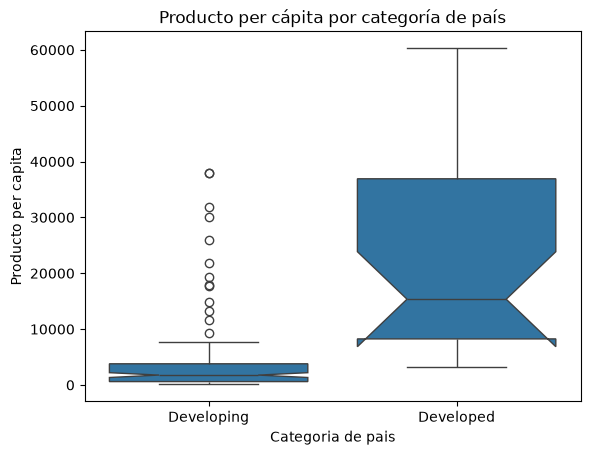

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro

#Hay varios paises que se repiten en distintos años, preparo por pais
datos_por_pais = (leer_datos_life_expectancy.groupby(["Country", "Status"], as_index=False)["GDP"].median())

sns.boxplot(x="Status", y="GDP", data=datos_por_pais, notch=True)
plt.title("Producto per cápita por categoría de país")
plt.xlabel("Categoria de pais")
plt.ylabel("Producto per capita")
plt.show()





In [26]:
#Probamos normalidad con Shapiro-Wilks
developed_countries = datos_por_pais.loc[datos_por_pais["Status"] == "Developed", "GDP"].dropna()
developing_countries = datos_por_pais.loc[datos_por_pais["Status"] == "Developing", "GDP"].dropna()

stat, p = shapiro(developed_countries)
print(f"Test de Shapiro-Wilk para países desarrollados: Estadístico={stat:.3f}, p-valor={p:.3f}")

stat, p = shapiro(developing_countries)
print(f"Test de Shapiro-Wilk para países en via de desarrollo: Estadístico={stat:.3f}, p-valor={p:.3f}")

Test de Shapiro-Wilk para países desarrollados: Estadístico=0.883, p-valor=0.005
Test de Shapiro-Wilk para países en via de desarrollo: Estadístico=0.546, p-valor=0.000


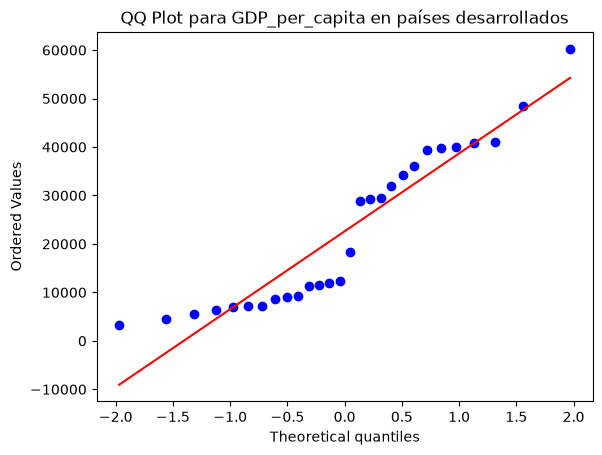

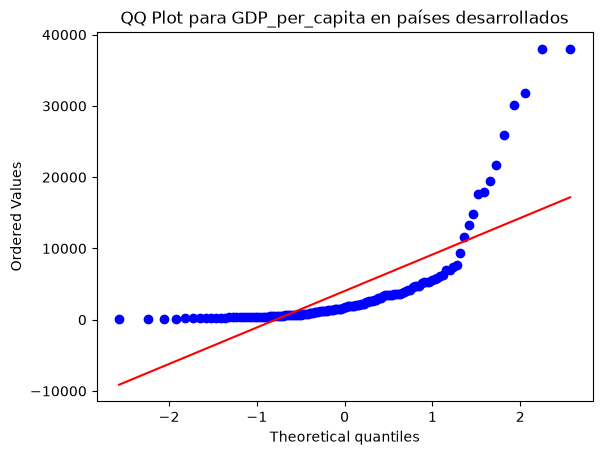

In [27]:
import scipy.stats as stats

stats.probplot(developed_countries, dist="norm", plot=plt)
plt.title("QQ Plot para GDP_per_capita en países desarrollados")
plt.show()

stats.probplot(developing_countries, dist="norm", plot=plt)
plt.title("QQ Plot para GDP_per_capita en países desarrollados")
plt.show()

In [28]:
#Validamos homocedasticidad
stat, p = stats.levene(developed_countries, developing_countries)
print(f"Test de Levene para GDP_per_capita: Estadístico={stat:.3f}, p-valor={p:.3f}")

Test de Levene para GDP_per_capita: Estadístico=54.511, p-valor=0.000


In [29]:
#Elijo Kruskal-Wallis porque no cumple con ningun supuesto
#H0: No existen diferencias significativas entre los dos grupos
#H1: Hay diferencia signi.
stat, p = stats.kruskal(developed_countries,developing_countries)
print(f"Test de Kruskal-Wallis para GDP_per_capita: Estadístico={stat:.3f}, p-valor={p:.3f}")

# Interpretación de los resultados
alpha = 0.05  # Nivel de significancia
if p > alpha:
    print("No hay suficiente evidencia para rechazar la hipótesis nula.")
    print("No hay una diferencia significativa en el GDP entre países desarrollados y en vías de desarrollo.")
else:
    print("Se rechaza la hipótesis nula.")
    print("Existe una diferencia significativa en el GDP entre países desarrollados y en vías de desarrollo.")

Test de Kruskal-Wallis para GDP_per_capita: Estadístico=50.801, p-valor=0.000
Se rechaza la hipótesis nula.
Existe una diferencia significativa en el GDP entre países desarrollados y en vías de desarrollo.


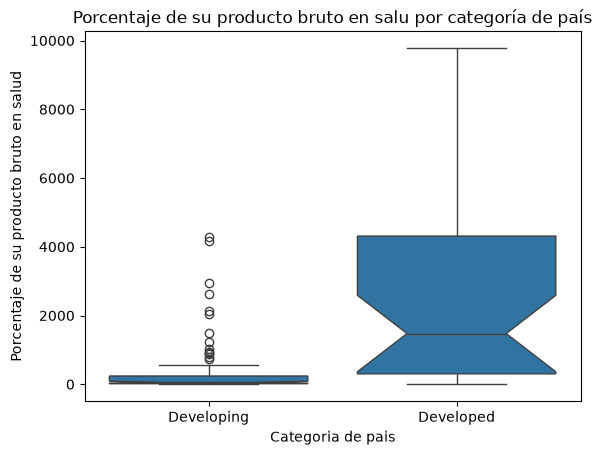

In [30]:
# Comprobar si los países en vías de desarrollo gastan un menor 
# porcentaje de su producto bruto en salud que los países desarrollados. 

datos_por_pais2 = (leer_datos_life_expectancy.groupby(["Country", "Status"], as_index=False)["percentage expenditure"].median())
sns.boxplot(x="Status", y="percentage expenditure", data=datos_por_pais2, notch=True)
plt.title("Porcentaje de su producto bruto en salu por categoría de país")
plt.xlabel("Categoria de pais")
plt.ylabel("Porcentaje de su producto bruto en salud")
plt.show()

In [31]:
developed_countries_porcentaje_salud = datos_por_pais2.loc[datos_por_pais["Status"] == "Developed", "percentage expenditure"].dropna()
developing_countries_porcentaje_salud = datos_por_pais2.loc[datos_por_pais["Status"] == "Developing", "percentage expenditure"].dropna()

stat, p = shapiro(developed_countries_porcentaje_salud)
print(f"Test de Shapiro-Wilk para países desarrollados: Estadístico={stat:.3f}, p-valor={p:.3f}")

stat, p = shapiro(developing_countries_porcentaje_salud)
print(f"Test de Shapiro-Wilk para países en via de desarrollo: Estadístico={stat:.3f}, p-valor={p:.3f}")

Test de Shapiro-Wilk para países desarrollados: Estadístico=0.858, p-valor=0.001
Test de Shapiro-Wilk para países en via de desarrollo: Estadístico=0.439, p-valor=0.000


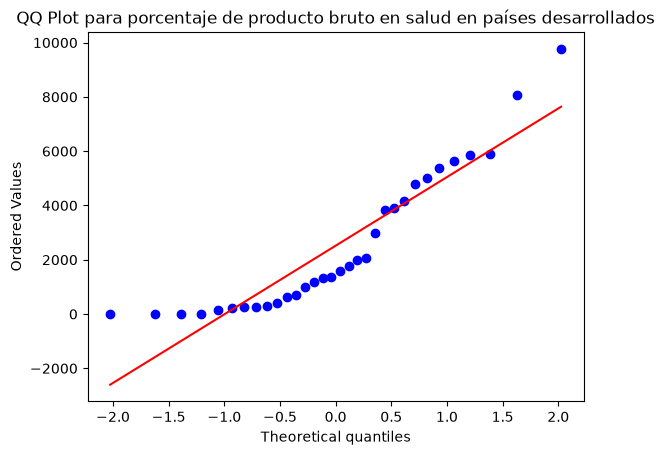

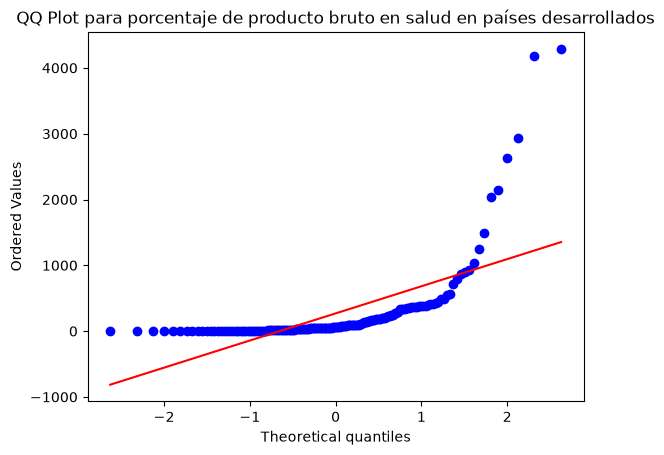

In [32]:
stats.probplot(developed_countries_porcentaje_salud, dist="norm", plot=plt)
plt.title("QQ Plot para porcentaje de producto bruto en salud en países desarrollados")
plt.show()

stats.probplot(developing_countries_porcentaje_salud, dist="norm", plot=plt)
plt.title("QQ Plot para porcentaje de producto bruto en salud en países desarrollados")
plt.show()

In [33]:
#Validamos homocedasticidad
stat, p = stats.levene(developed_countries_porcentaje_salud, developing_countries_porcentaje_salud)
print(f"Test de Levene para porcentaje de producto bruto en salud: Estadístico={stat:.3f}, p-valor={p:.3f}")

Test de Levene para porcentaje de producto bruto en salud: Estadístico=92.158, p-valor=0.000


In [34]:
#Elijo Kruskal-Wallis porque no cumple con ningun supuesto
#H0: No existen diferencias significativas entre los dos grupos
#H1: Hay diferencia signi.
stat, p = stats.kruskal(developed_countries_porcentaje_salud,developing_countries_porcentaje_salud)
print(f"Test de Kruskal-Wallis para porcentaje de producto bruto en salud: Estadístico={stat:.3f}, p-valor={p:.3f}")

# Interpretación de los resultados
alpha = 0.05  # Nivel de significancia
if p > alpha:
    print("No hay suficiente evidencia para rechazar la hipótesis nula.")
    print("No hay una diferencia significativa en el porcentaje de producto bruto en salud entre países desarrollados y en vías de desarrollo.")
else:
    print("Se rechaza la hipótesis nula.")
    print("Existe una diferencia significativa en el porcentaje de producto bruto en salud entre países desarrollados y en vías de desarrollo.")

Test de Kruskal-Wallis para porcentaje de producto bruto en salud: Estadístico=33.316, p-valor=0.000
Se rechaza la hipótesis nula.
Existe una diferencia significativa en el porcentaje de producto bruto en salud entre países desarrollados y en vías de desarrollo.


# Ejercicio 2

In [35]:
if not path.exists("Life-Expectancy-Data-Updated.csv"):
    download("https://ignaciorlando.github.io/datasets/data-science/Life-Expectancy-Data-Updated.csv")
else:
    print("El archivo ya existe")

leer_datos_life_expectancy_update = pd.read_csv("Life-Expectancy-Data-Updated.csv")
leer_datos_life_expectancy_update.head()

El archivo ya existe


,Country,Region,Year,Infant_deaths,Under_five_deaths,Adult_mortality,Alcohol_consumption,Hepatitis_B,Measles,BMI,...,Diphtheria,Incidents_HIV,GDP_per_capita,Population_mln,Thinness_ten_nineteen_years,Thinness_five_nine_years,Schooling,Economy_status_Developed,Economy_status_Developing,Life_expectancy
0,Turkiye,Middle East,2015,11.1,13.0,105.8240,1.32,97,65,27.8,...,97,0.08,11006,78.53,4.9,4.8,7.8,0,1,76.5
1,Spain,European Union,2015,2.7,3.3,57.9025,10.35,97,94,26.0,...,97,0.09,25742,46.44,0.6,0.5,9.7,1,0,82.8
2,India,Asia,2007,51.5,67.9,201.0765,1.57,60,35,21.2,...,64,0.13,1076,1183.21,27.1,28.0,5.0,0,1,65.4
3,Guyana,South America,2006,32.8,40.5,222.1965,5.68,93,74,25.3,...,93,0.79,4146,0.75,5.7,5.5,7.9,0,1,67.0
4,Israel,Middle East,2012,3.4,4.3,57.9510,2.89,97,89,27.0,...,94,0.08,33995,7.91,1.2,1.1,12.8,1,0,81.7


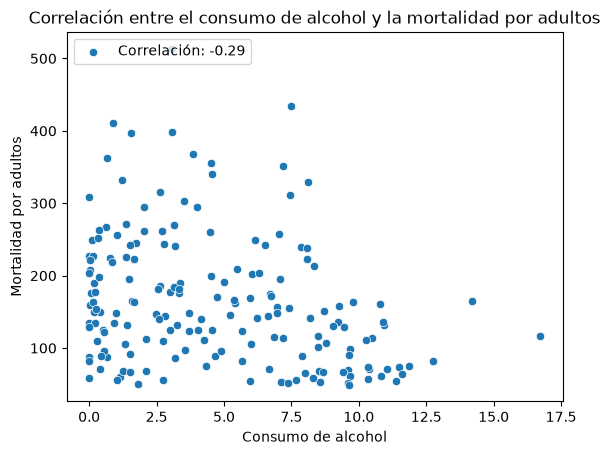

In [40]:
#Primera hipotesis, el consumo de alcohol (Alcohol_consumption) esta relacionado con muerte de adultos (Adult_mortality)
datos_por_pais_ultimo = (leer_datos_life_expectancy_update.sort_values('Year').groupby('Country', as_index=False).tail(1).reset_index(drop=True))
coeficiente_correlacion = stats.pearsonr(datos_por_pais_ultimo['Alcohol_consumption'], datos_por_pais_ultimo['Adult_mortality'])

sns.scatterplot(x='Alcohol_consumption', y='Adult_mortality', data=datos_por_pais_ultimo)
plt.legend([f"Correlación: {coeficiente_correlacion[0]:.2f}"], loc='upper left')
plt.title('Correlación entre el consumo de alcohol y la mortalidad por adultos')
plt.xlabel('Consumo de alcohol')
plt.ylabel('Mortalidad por adultos')
plt.show()


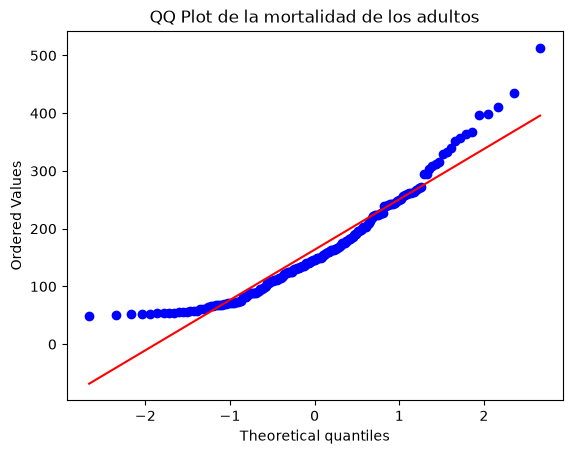

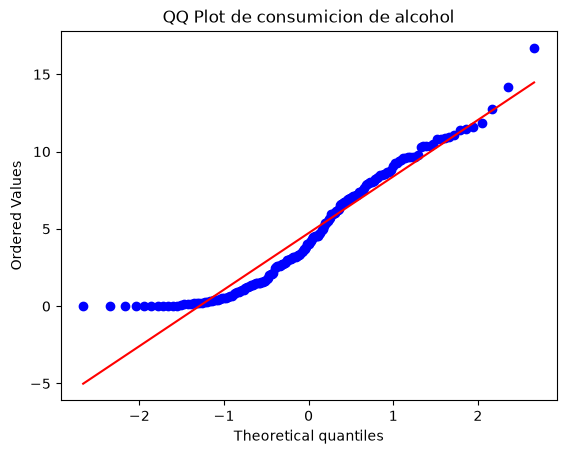

In [42]:
#Supuesto normalidad

stats.probplot(datos_por_pais_ultimo["Adult_mortality"], dist="norm", plot=plt)
plt.title("QQ Plot de la mortalidad de los adultos")
plt.show()

stats.probplot(datos_por_pais_ultimo["Alcohol_consumption"], dist="norm", plot=plt)
plt.title("QQ Plot de consumicion de alcohol")
plt.show()

In [45]:
#Validamos homocedasticidad

stat, p = stats.levene(datos_por_pais_ultimo["Adult_mortality"], datos_por_pais_ultimo["Alcohol_consumption"])
print(f"Test de Levene para GDP_per_capita: Estadístico={stat:.3f}, p-valor={p:.3f}")

Test de Levene para GDP_per_capita: Estadístico=213.816, p-valor=0.000


__Hipotesis 2:__ Existe una relación entre los años de escolaridad (Schooling) y la expectativa de vida (Life_expectancy).

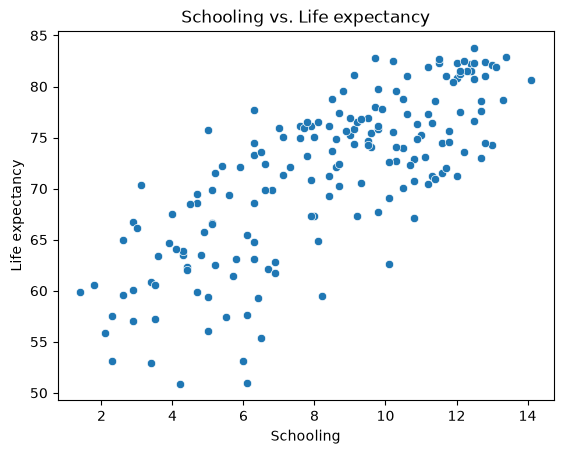

In [46]:
datos_schooling = datos_por_pais_ultimo[["Country", "Year", "Schooling", "Life_expectancy"]].dropna()
sns.scatterplot(x="Schooling", y="Life_expectancy", data=datos_schooling)
plt.title("Schooling vs. Life expectancy")
plt.xlabel("Schooling")
plt.ylabel("Life expectancy")
plt.show()

In [47]:
#Validar normalidad
stat, p = shapiro(datos_schooling["Schooling"])
print(f"Test de Shapiro-Wilk para Schooling: Estadístico={stat:.3f}, p-valor={p:.3f}")

stat, p = shapiro(datos_schooling["Life_expectancy"])
print(f"Test de Shapiro-Wilk para Life_expectancy: Estadístico={stat:.3f}, p-valor={p:.3f}")

Test de Shapiro-Wilk para Schooling: Estadístico=0.962, p-valor=0.000
Test de Shapiro-Wilk para Life_expectancy: Estadístico=0.953, p-valor=0.000


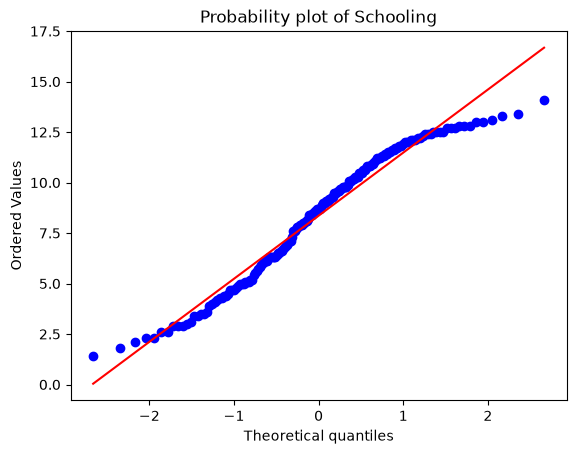

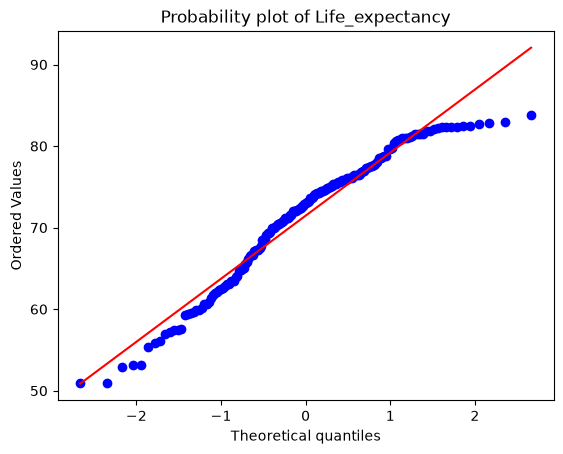

In [48]:
stats.probplot(datos_schooling["Schooling"], dist="norm", plot=plt)
plt.title("Probability plot of Schooling")
plt.show()

stats.probplot(datos_schooling["Life_expectancy"], dist="norm", plot=plt)
plt.title("Probability plot of Life_expectancy")
plt.show()

In [49]:
stat, p = stats.levene(datos_schooling["Schooling"], datos_schooling["Life_expectancy"])
print(f"Test de Levene: Estadístico={stat:.3f}, p-valor={p:.3f}")

Test de Levene: Estadístico=85.752, p-valor=0.000


In [ ]:
# Test de Kruskal-Wallis
stat, p = stats.kruskal(datos_schooling["Schooling"], datos_schooling["Life_expectancy"])
print(f"Test de Kruskal-Wallis para Schoolig y Life: Estadístico={stat:.3f}, p-valor={p:.3f}")

# Interpretación de los resultados
alpha = 0.05  # Nivel de significancia
if p > alpha:
    print("No hay suficiente evidencia para rechazar la hipótesis nula.")
else:
    print("Se rechaza la hipótesis nula.")

Test de Kruskal-Wallis para Schoolig y Life: Estadístico=267.761, p-valor=0.000
Se rechaza la hipótesis nula.
